## Initial Set Up


In [1]:
import os

import sys
!{sys.executable} -m pip install --upgrade pip
print(sys.version)
print(sys.executable)

3.10.13 (main, Feb 19 2026, 23:33:18) [Clang 17.0.0 (clang-1700.6.3.2)]
/Users/sritama/.pyenv/versions/3.10.13/bin/python


In [2]:
%pip install spacy==3.6.1
%pip install scispacy==0.5.3
%pip install medspacy
%pip install gensim
%pip install umap-learn

  Using cached typer-0.9.4-py3-none-any.whl.metadata (14 kB)
Using cached typer-0.9.4-py3-none-any.whl (45 kB)
  Attempting uninstall: typer
    Found existing installation: typer 0.24.1
    Uninstalling typer-0.24.1:
      Successfully uninstalled typer-0.24.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer-slim 0.24.0 requires typer>=0.24.0, but you have typer 0.9.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pandas
%pip install numpy
%pip install scikit-learn
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np

from gensim.models import Word2Vec

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

import umap

/Users/sritama/.pyenv/versions/3.10.13/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Build AMI Cohort

In [5]:
# data_location denotes the location of the MIMIC-III dataset on your local machine. Change this path if your dataset is located elsewhere. Due to the size of the dataset, it is recommended to download the dataset and store it in a local directory. The dataset can be downloaded from the following link: https://physionet.org/content/mimiciii/1.4/


# Update this path to your local MIMIC-III directory
data_location = "../../../Documents/Learning/MS_AI/AI_In_Healthcare/Dataset/mimic-iii-clinical-database-1.4/"
print(os.path.exists(data_location))  # Should print True

True


In [6]:
folder_name = "images"

# Create images folder if it doesn't exist. This is where we'll save all our plots.
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

print(os.path.exists(folder_name))  # Should print True

True


In [7]:
# Load ICD diagnoses
diagnoses = pd.read_csv(data_location + "DIAGNOSES_ICD.csv.gz")

# Filter AMI (ICD-9 410.xx)
ami = diagnoses[diagnoses['ICD9_CODE'].str.startswith('410', na=False)]

ami_hadm_ids = ami['HADM_ID'].unique()
print("Number of AMI admissions:", len(ami_hadm_ids))

subj_filtered = ami['SUBJECT_ID'].unique()
print("Number of unique AMI patients:", len(subj_filtered))

Number of AMI admissions: 5430
Number of unique AMI patients: 5032


##### Extract AMI Discharge Summaries

In [8]:
notes = pd.read_csv(
    data_location + "NOTEEVENTS.csv.gz",
    compression='gzip',
    dtype={
        'SUBJECT_ID': 'int32',
        'HADM_ID': 'float32',   # some rows missing
        'CATEGORY': 'category',
        'DESCRIPTION': 'category'
    },
    parse_dates=['CHARTDATE', 'CHARTTIME'],
    low_memory=False
)

notes.info()
notes.iloc[0]
print(notes.iloc[0]['TEXT'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2083180 entries, 0 to 2083179
Data columns (total 11 columns):
 #   Column       Dtype         
---  ------       -----         
 0   ROW_ID       int64         
 1   SUBJECT_ID   int32         
 2   HADM_ID      float32       
 3   CHARTDATE    datetime64[ns]
 4   CHARTTIME    datetime64[ns]
 5   STORETIME    object        
 6   CATEGORY     category      
 7   DESCRIPTION  category      
 8   CGID         float64       
 9   ISERROR      float64       
 10  TEXT         object        
dtypes: category(2), datetime64[ns](2), float32(1), float64(2), int32(1), int64(1), object(2)
memory usage: 133.3+ MB
Admission Date:  [**2151-7-16**]       Discharge Date:  [**2151-8-4**]


Service:
ADDENDUM:

RADIOLOGIC STUDIES:  Radiologic studies also included a chest
CT, which confirmed cavitary lesions in the left lung apex
consistent with infectious process/tuberculosis.  This also
moderate-sized left pleural effusion.

HEAD CT:  Head CT showed no

In [9]:
ami_notes = notes[
    (notes['HADM_ID'].isin(ami_hadm_ids)) &
    (notes['CATEGORY'] == 'Discharge summary')
]


# ami_notes = ami_notes.dropna(subset=['TEXT']).sample(1000, random_state=42)
ami_notes = notes[
    (notes['HADM_ID'].isin(ami_hadm_ids)) &
    (notes['CATEGORY'] == 'Discharge summary')
].dropna(subset=['TEXT'])

# texts = ami_notes['TEXT'].tolist()
texts = ami_notes['TEXT'].sample(1000, random_state=42).tolist()


print("AMI discharge summaries:", len(texts))

AMI discharge summaries: 1000


In [10]:
## We may not need to filter by SUBJECT_ID since HADM_ID is already specific to AMI admissions - so this whole section may be redundant. 

# ami_notes = notes[
#     (notes['HADM_ID'].isin(ami_hadm_ids)) &
#     (notes['CATEGORY'] == 'Discharge summary') &
#     (notes['SUBJECT_ID'].isin(subj_filtered))
# ]

# arr_subject_id=[]
# arr_hadm_id=[]
# arr_icd9_code=[]
# for row in range(0, len(diagnoses)):
#   code = str(diagnoses.loc[row, 'ICD9_CODE'])
#   if code.startswith('410'):
#     arr_subject_id.append(diagnoses.loc[row, 'SUBJECT_ID'])
#     arr_hadm_id.append(diagnoses.loc[row, 'HADM_ID'])
#     arr_icd9_code.append(code)

#     # print(diagnoses.loc[row, 'SUBJECT_ID'])
# print('length of array is:',len(arr_subject_id))

In [11]:
ami_notes.info()

# We may want to modify the dataframe to remove unnecessary columns or clean up data
# ami_notes = ami_notes.drop(columns=['ROW_ID', 'CHARTDATE', 'CHARTTIME', 'STORETIME'])


<class 'pandas.core.frame.DataFrame'>
Index: 6183 entries, 10 to 60388
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ROW_ID       6183 non-null   int64         
 1   SUBJECT_ID   6183 non-null   int32         
 2   HADM_ID      6183 non-null   float32       
 3   CHARTDATE    6183 non-null   datetime64[ns]
 4   CHARTTIME    0 non-null      datetime64[ns]
 5   STORETIME    0 non-null      object        
 6   CATEGORY     6183 non-null   category      
 7   DESCRIPTION  6183 non-null   category      
 8   CGID         0 non-null      float64       
 9   ISERROR      0 non-null      float64       
 10  TEXT         6183 non-null   object        
dtypes: category(2), datetime64[ns](2), float32(1), float64(2), int32(1), int64(1), object(2)
memory usage: 612.6+ KB


## Install the models

In [12]:
# Install en_core_web_sm model for spaCy

%pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.6.0/en_core_web_sm-3.6.0-py3-none-any.whl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 31.6 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [13]:
# Install en_core_sci_md model for SciSpaCy

%pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.3/en_core_sci_md-0.5.3.tar.gz

  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.3/en_core_sci_md-0.5.3.tar.gz (119.1 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


##### tSNE Model Config

In [14]:

# tsne_config = TSNE(
#     n_components=2,
#     perplexity=20, 
#     learning_rate='auto',
#     max_iter=3000,
#     metric='cosine',
#     random_state=42
# )

tsne_config = TSNE(
    n_components=2,
    perplexity=30, 
    early_exaggeration=12,
    init='pca',
    max_iter=5000,
    metric='cosine',
    random_state=23
)


## spaCy

##### Entity Extraction (AMI)

In [15]:
import spacy

nlp_spacy = spacy.load("en_core_web_sm")

spacy_entities_docs = []

for doc in nlp_spacy.pipe(texts, batch_size=10):
    entities = [ent.text.lower() for ent in doc.ents]
    spacy_entities_docs.append(entities)

print("Sample spaCy entities:", spacy_entities_docs[:20])

Sample spaCy entities: [['2107-9-10', '2107-9-14', 'date of birth:', '2072-11-19', '35-year-old', 'emergency medical service', 'one', 'the emergency department', 'v2', 'v6', 'lopressor', '346', 'orthopnea', '40s', '132/78', '95', '13', '90%', '6', 'sclerae', 'first', 'second', 'femoral', 'neurologic', 'three', 'pertinent laboratory data', 'laboratories', '16.2', '48', '69', 'alt', '227', 'ast', '512', '4787', '555', '11.6', '238', '93', '41', '178', 'electrocardiogram', 'v3', 'v5', 'ii', '16', '42/12', '42/25', '35', '30', '90%', 'angio-jet', '1', 'coronary care unit', 'plavix', '18-hour', 'lopressor', 'the coronary care unit', '9-12', '30%', 'coumadin', 'coumadin', 'statin', '2', 'discharge', '1', 'aspirin 325', 'p.o', '2', '3', 'coumadin 5 mg p.o', 'q.d.', '4', 'lopressor 37.5', '5', 'discharge instructions/followup', '1', 'cardiology', 'the\noutpatient clinic', '2', '197', 'clinic', 'inr', 'first', '12', 'md', '9508', '2108-1-18', '2108-1-20'], ['2151-2-12', '2151-2-25', '1', '2', '

##### Optional: displaCy for the spaCy model

In [16]:
from spacy import displacy

doc_example = nlp_spacy(texts[0])
displacy.render(doc_example, style="ent", jupyter=True)

##### Train Word2Vec on spaCy Entities

In [17]:

w2v_spacy = Word2Vec(
    sentences=spacy_entities_docs,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4
)

##### Tuned t-SNE (spaCy)

In [18]:
words = w2v_spacy.wv.index_to_key[:200]
vectors = np.array([w2v_spacy.wv[w] for w in words])

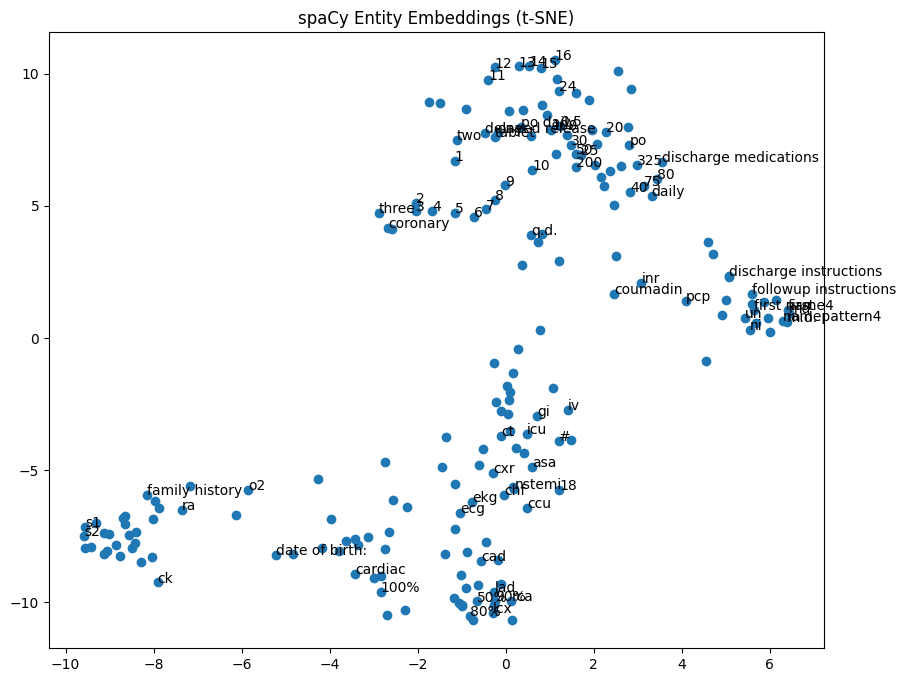

In [19]:
tsne = tsne_config

reduced = tsne.fit_transform(vectors)

plt.figure(figsize=(10,8))
plt.scatter(reduced[:,0], reduced[:,1])
for i, word in enumerate(words[:80]):
    plt.annotate(word, (reduced[i,0], reduced[i,1]))
plt.title("spaCy Entity Embeddings (t-SNE)")
plt.savefig("images/spacy_tsne_config.png", dpi=300, bbox_inches="tight")
plt.show()

##### UMAP for Spacy Model

/Users/sritama/.pyenv/versions/3.10.13/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


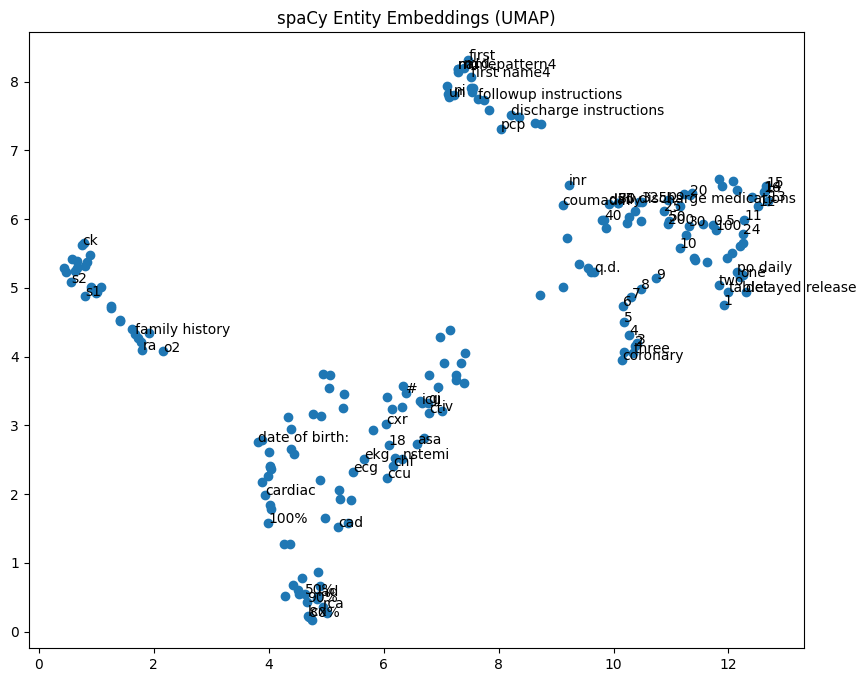

In [20]:
# reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, random_state=42)
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding = reducer.fit_transform(vectors)

plt.figure(figsize=(10,8))
plt.scatter(embedding[:,0], embedding[:,1])
for i, word in enumerate(words[:80]):
    plt.annotate(word, (embedding[i,0], embedding[i,1]))
plt.title("spaCy Entity Embeddings (UMAP)")
plt.savefig("images/spacy_umap.png", dpi=300, bbox_inches="tight")

plt.show()

## SciSpaCy

##### SciSpaCy Entity Extraction (AMI)

In [21]:
nlp_sci = spacy.load("en_core_sci_md")

scispacy_entities_docs = []

for doc in nlp_sci.pipe(texts, batch_size=10):
    entities = [ent.text.lower() for ent in doc.ents]
    scispacy_entities_docs.append(entities)

print("Sample SciSpaCy entities:", scispacy_entities_docs[:20])

/Users/sritama/.pyenv/versions/3.10.13/lib/python3.10/site-packages/spacy/language.py:2141: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


Sample SciSpaCy entities: [['admission', 'discharge date', 'sex', 'ccu', 'patient', 'male', 'no significant', 'medical history', 'yard', 'sudden onset', 'right-sided chest', 'radiation', 'diaphoretic', 'dyspnea', 'lightheadedness', 'collapsed', 'brother', 'cardiopulmonary resuscitation', 'arrival', 'emergency medical service', 'patient', 'ventricular fibrillation arrest', 'patient', 'shocked', 'return of sinus rhythm', 'patient', 'hospital', 'emergency department', 'electrocardiogram', 'infarct', 'st', 'changes', 'elevations', 'v6', 'patient', 'aspirin', 'lopressor', 'heparin', 'nitroglycerin drip', 'integrilin', 'transferred', '[**hospital1 346**]', 'cardiac catheterization', 'patient', 'chest pain', 'dyspnea', 'exertion', 'orthopnea', 'paroxysmal nocturnal dyspnea', 'edema', 'smoking', 'hypercholesterolemia', 'diabetes', 'cocaine use', 'past', 'past medical history', 'sleep\napnea', 'psoriasis', 'homeopathic shakes', 'breakfast', 'patient', 'drug allergies', 'family history', 'died',

##### Optional: displaCy for the ScispaCy model

In [22]:
scispaCydoc_example = nlp_sci(texts[0])
displacy.render(scispaCydoc_example, style="ent", jupyter=True)

##### Word2Vec (SciSpaCy)

In [23]:
w2v_sci = Word2Vec(
    sentences=scispacy_entities_docs,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4
)

##### Tuned t-SNE (SciSpaCy)

In [24]:
words_sci = w2v_sci.wv.index_to_key[:200]
vectors_sci = np.array([w2v_sci.wv[w] for w in words_sci])

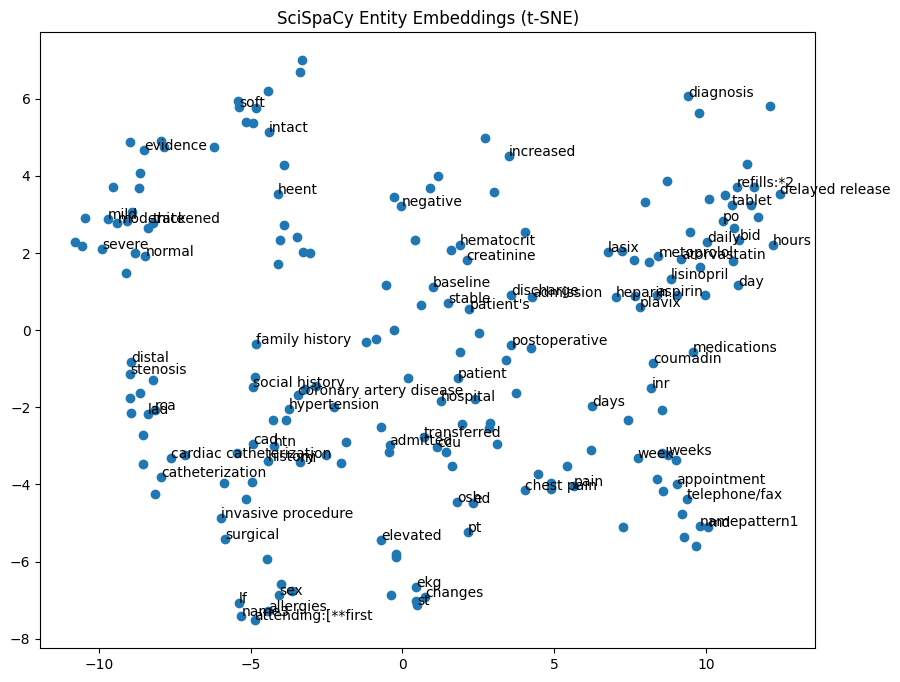

In [25]:
tsne = tsne_config

reduced_sci = tsne.fit_transform(vectors_sci)

plt.figure(figsize=(10,8))
plt.scatter(reduced_sci[:,0], reduced_sci[:,1])
for i, word in enumerate(words_sci[:80]):
    plt.annotate(word, (reduced_sci[i,0], reduced_sci[i,1]))
plt.title("SciSpaCy Entity Embeddings (t-SNE)")
plt.savefig("images/SciSpacy_tsne_config.png", dpi=300, bbox_inches="tight")
plt.show()

##### UMAP (SciSpaCy)

/Users/sritama/.pyenv/versions/3.10.13/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


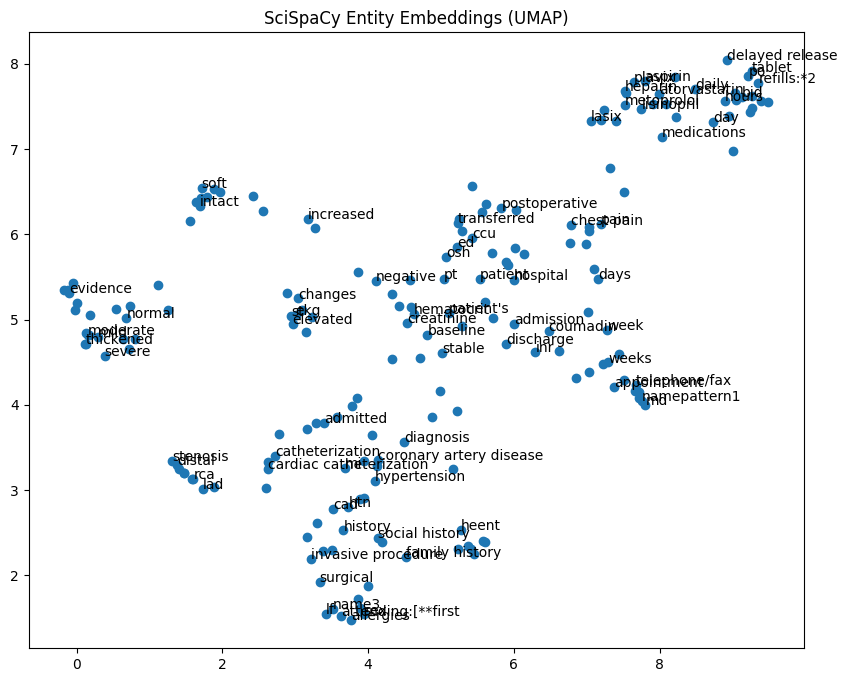

In [26]:
# reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, random_state=42)
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
embedding_sci = reducer.fit_transform(vectors_sci)

plt.figure(figsize=(10,8))
plt.scatter(embedding_sci[:,0], embedding_sci[:,1])
for i, word in enumerate(words_sci[:80]):
    plt.annotate(word, (embedding_sci[i,0], embedding_sci[i,1]))
plt.title("SciSpaCy Entity Embeddings (UMAP)")
plt.savefig("images/SciSpacy_umap.png", dpi=300, bbox_inches="tight")
plt.show()

## MedSpacy

##### medSpaCy Entity Extraction (AMI)

In [27]:
import logging
logging.basicConfig(level=logging.ERROR)

from loguru import logger
logger.remove() 

In [28]:
import medspacy

# nlp_med = medspacy.load()  ## Use medspacy's different  clinical model

nlp_med = medspacy.load("en_core_sci_md", disable=["parser"]) 

In [29]:

medspacy_entities_docs = []

for doc in nlp_med.pipe(texts, batch_size=10):
    entities = [ent.text.lower() for ent in doc.ents]
    medspacy_entities_docs.append(entities)

print("Sample medspacy entities:", medspacy_entities_docs[:20])



Sample medspacy entities: [['admission', 'discharge date', 'sex', 'ccu', 'patient', 'year', 'old', 'male', 'no significant', 'medical history', 'yard', 'sudden onset', 'right', 'sided chest', 'radiation', 'diaphoretic', 'dyspnea', 'lightheadedness', 'collapsed', 'brother', 'cardiopulmonary resuscitation', 'arrival', 'emergency medical service', 'patient', 'ventricular fibrillation arrest', 'patient', 'shocked', 'return of sinus rhythm', 'patient', 'hospital', 'emergency department', 'electrocardiogram', 'infarct', 'st', 'changes', 'elevations', 'v6', 'patient', 'aspirin', 'lopressor', 'heparin', 'nitroglycerin drip', 'integrilin', 'transferred', '[**hospital1 346**]', 'cardiac catheterization', 'patient', 'chest pain', 'dyspnea', 'exertion', 'orthopnea', 'paroxysmal nocturnal dyspnea', 'edema', 'smoking', 'hypercholesterolemia', 'diabetes', 'cocaine use', 'past', 'past medical history', 'sleep\napnea', 'psoriasis', 'homeopathic shakes', 'breakfast', 'patient', 'drug allergies', 'family

##### Optional : displaCy for the medSpaCy model

In [30]:
medspacydoc_example = nlp_med(texts[0])
displacy.render(medspacydoc_example, style="ent", jupyter=True)

##### Word2Vec (medSpaCy)

In [31]:
w2v_med = Word2Vec(
    sentences=medspacy_entities_docs,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


##### Tuned t-SNE (medSpaCy)

In [32]:
words_med = w2v_med.wv.index_to_key[:200]
vectors_med = np.array([w2v_med.wv[w] for w in words_med])

print(len(w2v_med.wv.index_to_key))

print(w2v_med.wv.most_similar(w2v_med.wv.index_to_key[0]))

11836
[('disp', 0.9569839239120483), ('lisinopril 5', 0.9534704685211182), ('chewable', 0.9462888240814209), ('lisinopril 2.5', 0.942277193069458), ('po', 0.938204824924469), ('cholecalciferol', 0.9356510639190674), ('chewable sig', 0.9300661087036133), ('donepezil', 0.9263039827346802), ('lansoprazole', 0.9247868657112122), ('hcl', 0.9221230745315552)]


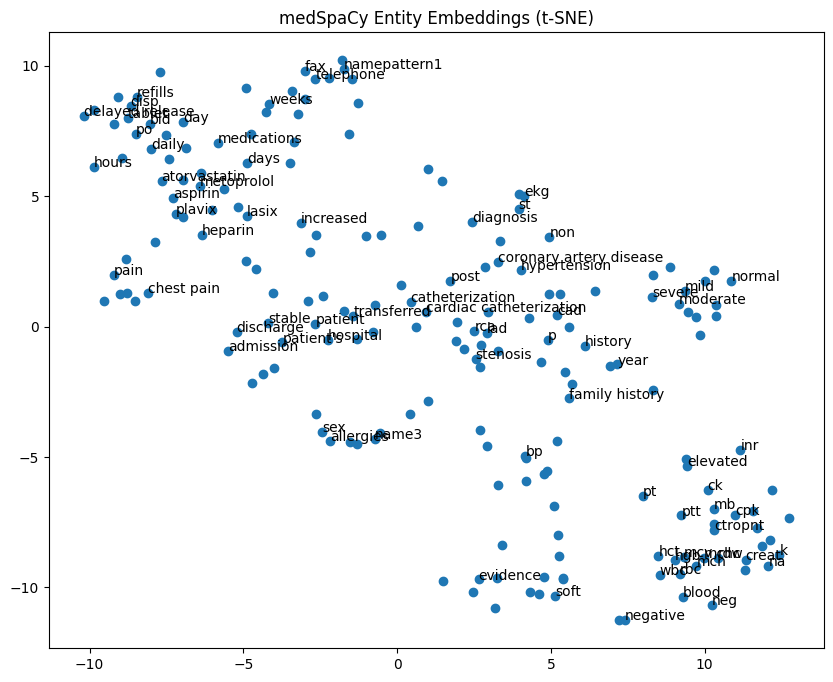

In [33]:
tsne = tsne_config

reduced_med = tsne.fit_transform(vectors_med)

plt.figure(figsize=(10,8))
plt.scatter(reduced_med[:,0], reduced_med[:,1])
for i, word in enumerate(words_med[:80]):
    plt.annotate(word, (reduced_med[i,0], reduced_med[i,1]))

plt.title("medSpaCy Entity Embeddings (t-SNE)")
plt.savefig("images/MedSpacy_tsne_config.png", dpi=300, bbox_inches="tight")
plt.show()

UMAP (medSpaCy)

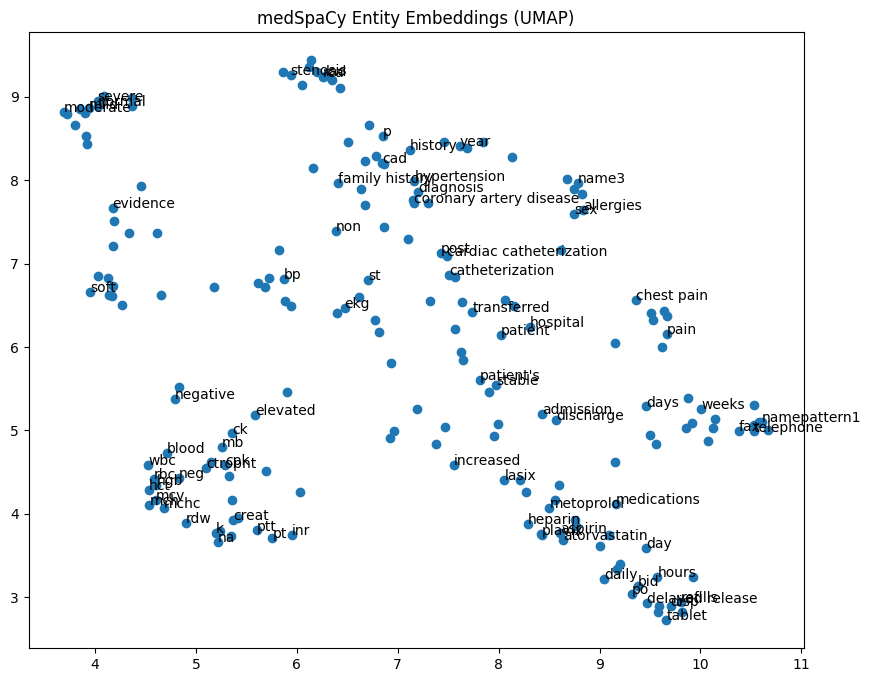

In [34]:
#reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, random_state=42)
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
embedding_med = reducer.fit_transform(vectors_med)

plt.figure(figsize=(10,8))
plt.scatter(embedding_med[:,0], embedding_med[:,1])
for i, word in enumerate(words_med[:80]):
    plt.annotate(word, (embedding_med[i,0], embedding_med[i,1]))
plt.title("medSpaCy Entity Embeddings (UMAP)")
plt.savefig("images/medSpacy_umap.png", dpi=300, bbox_inches="tight")
plt.show()

## Bonus: ClinicalBERT on AMI

In [35]:
%pip install transformers

%pip install torch

  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
Using cached typer-0.24.1-py3-none-any.whl (56 kB)
  Attempting uninstall: typer
    Found existing installation: typer 0.9.4
    Uninstalling typer-0.9.4:
      Successfully uninstalled typer-0.9.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spacy 3.6.1 requires typer<0.10.0,>=0.3.0, but you have typer 0.24.1 which is incompatible.
weasel 0.3.4 requires typer<0.10.0,>=0.3.0, but you have typer 0.24.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


##### Load BioClinicalBERT

In [36]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

model_name = "emilyalsentzer/Bio_ClinicalBERT"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

model.eval()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2801.35it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

##### Create Contextual Embeddings

In [37]:
def get_mean_embedding(text):
    inputs = tokenizer(
        text[:512],
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)

    last_hidden = outputs.last_hidden_state
    attention_mask = inputs["attention_mask"]

    mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    masked_embeddings = last_hidden * mask

    mean_embedding = masked_embeddings.sum(1) / mask.sum(1)
    
    return mean_embedding.squeeze().numpy()

In [38]:
sample_texts = texts[:300]

bert_embeddings = np.vstack(
    [get_mean_embedding(t) for t in sample_texts]
)

print("Embedding shape:", bert_embeddings.shape)

Embedding shape: (300, 768)


##### Tuned t-SNE (ClinicalBERT)

In [39]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    max_iter=3000,
    metric="cosine",
    init="pca",
    random_state=42
)

tsne_embedding = tsne.fit_transform(bert_embeddings)


In [40]:
from collections import Counter

def most_frequent_entity(entities):
    """
    entities: list of entity strings extracted from a single document
    returns: most frequent entity string
    """
    if not entities:
        return "none"
    
    normalized = [e.lower().strip() for e in entities]
    counts = Counter(normalized)

    most_common_entity = counts.most_common(1)[0][0]
    
    return most_common_entity

In [41]:
primary_labels = []

for ents in scispacy_entities_docs[:len(tsne_embedding)]:
    if len(ents) > 0:
        # primary_labels.append(ents[0])
        primary_labels.append(most_frequent_entity(ents))
    else:
        primary_labels.append("none")

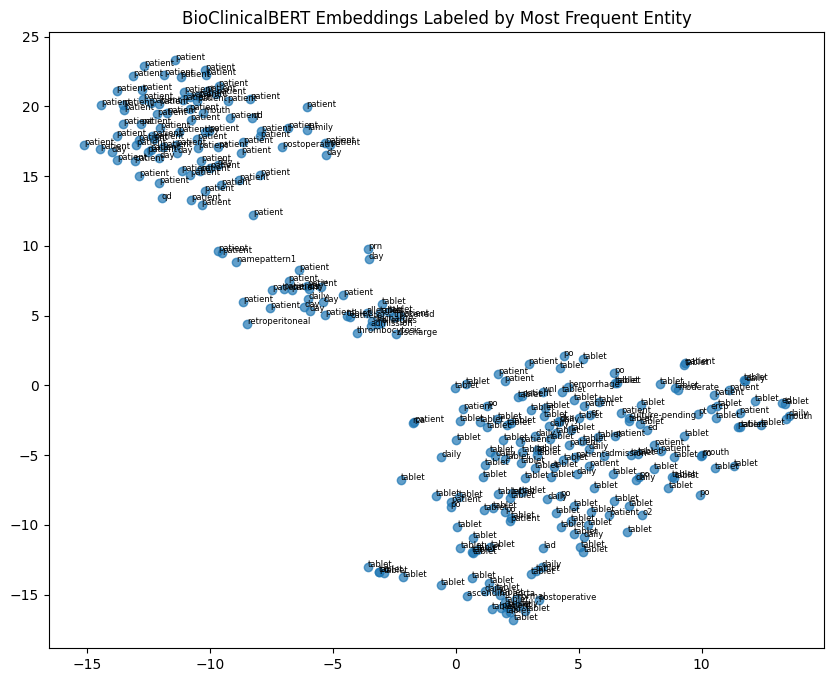

In [42]:
plt.figure(figsize=(10,8))

plt.scatter(tsne_embedding[:,0],
            tsne_embedding[:,1],
            alpha=0.7)

for i, label in enumerate(primary_labels):
    plt.annotate(
        label,
        (tsne_embedding[i,0], tsne_embedding[i,1]),
        fontsize=6
    )

plt.title("BioClinicalBERT Embeddings Labeled by Most Frequent Entity")
plt.savefig("images/bioclinicalbert_tsne.png", dpi=300, bbox_inches="tight")
plt.show()